In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [2]:
CST_T1  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_T1_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_GM_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_WM_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_CSF = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CSF_slope.tsv'), sep = '\t')  # slope for each subject at L/R CST

In [3]:
print(CST_T1.loc[CST_T1[CST_T1.isPatient == 0]['mean'].idxmin(), 'subj_id'])

#CST_T1[CST_T1.subj_id == 'JHP_1004']
CST_T1 = CST_T1[CST_T1.subj_id != 'JHP_1004']
CST_T1 = CST_T1[CST_T1.subj_id != 'UZP_1006']
CST_T1 = CST_T1[CST_T1.subj_id != 'UZP_1001']

JHP_1004


In [4]:
# lesioned side is always right in patients
t1_r_patients = np.array(CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname == 'right_CST')]['mean'])
t1_l_patients = np.array(CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname == 'left_CST')]['mean'])
t1_bilat_controls = np.array(CST_T1[CST_T1.isPatient == 0]['mean'])


controls_t1 = CST_T1[CST_T1.isPatient == 0]
controls_bilat_t1 = controls_t1.groupby('subj_id').agg({'mean': 'mean'}).reset_index()
controls_bilat_t1['regionname'] = 'bilat_CST'
controls_bilat_t1['isPatient'] = 0

patients_t1 = CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname.isin(['left_CST', 'right_CST']))]

cst_t1 = pd.concat([patients_t1, controls_bilat_t1], ignore_index=True)

**t-test for CST: lesion side in patients, controls** 
 t-value: -2.0833788978780117 	 p-value: 0.0423493813074076


**t-test for CST: non-lesion side in patients, controls** 
 t-value: -1.0147480538198508 	 p-value: 0.3151113272670896


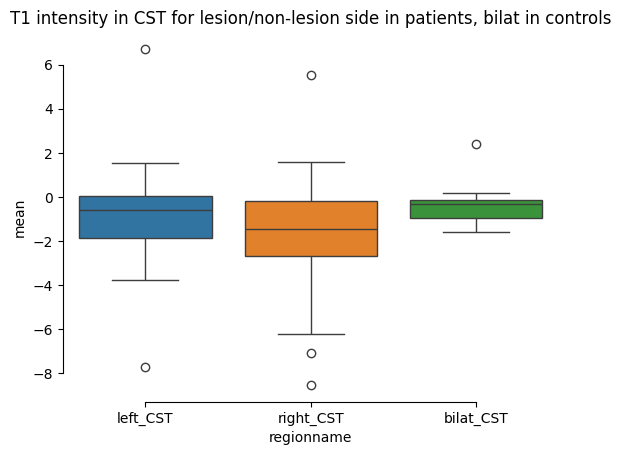

In [5]:
t_val, p_val = stats.ttest_ind(t1_r_patients, t1_bilat_controls)
print(f'**t-test for CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(t1_l_patients, t1_bilat_controls)
print(f'**t-test for CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', showfliers=True)

sns.despine(trim = True)
plt.title('T1 intensity in CST for lesion/non-lesion side in patients, bilat in controls')
plt.show()

In [6]:
t_val, p_val = stats.ttest_rel(t1_r_patients, t1_l_patients)
print(f'**t-test for CST: within patients, left, right hemisphers** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

**t-test for CST: within patients, left, right hemisphers** 
 t-value: -4.207324808992538 	 p-value: 0.00017067319112679078


